### Imports and Environment Setup

In [26]:

import cv2
import numpy as np
import matplotlib.pyplot as plt

# For Jupyter display
%matplotlib inline

print("OpenCV version:", cv2.__version__)


OpenCV version: 4.13.0


### Load and Inspect Video Data

(np.float64(-0.5), np.float64(1279.5), np.float64(719.5), np.float64(-0.5))

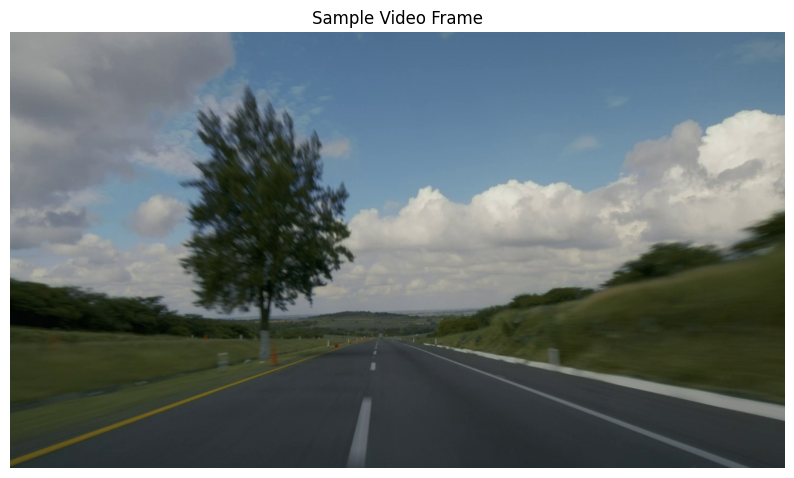

In [27]:

video_path = "LD.mp4"   # Change to local path
capture = cv2.VideoCapture(video_path)

if not capture.isOpened():
    raise IOError("Cannot open video file")

ret, frame = capture.read()
capture.release()

# OpenCV uses BGR → convert to RGB
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(frame_rgb)
plt.title("Sample Video Frame")
plt.axis("off")


### Preprocessing

(np.float64(-0.5), np.float64(1279.5), np.float64(719.5), np.float64(-0.5))

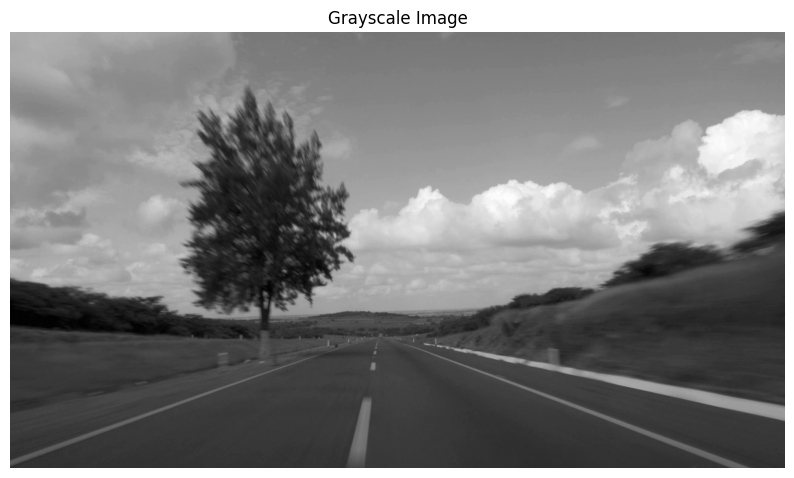

In [28]:
# Convert to Grayscale

def grayscale(img):
    return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

gray = grayscale(frame_rgb)

plt.figure(figsize=(10, 6))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")


### Noise Reduction with Gaussian Blur

(np.float64(-0.5), np.float64(1279.5), np.float64(719.5), np.float64(-0.5))

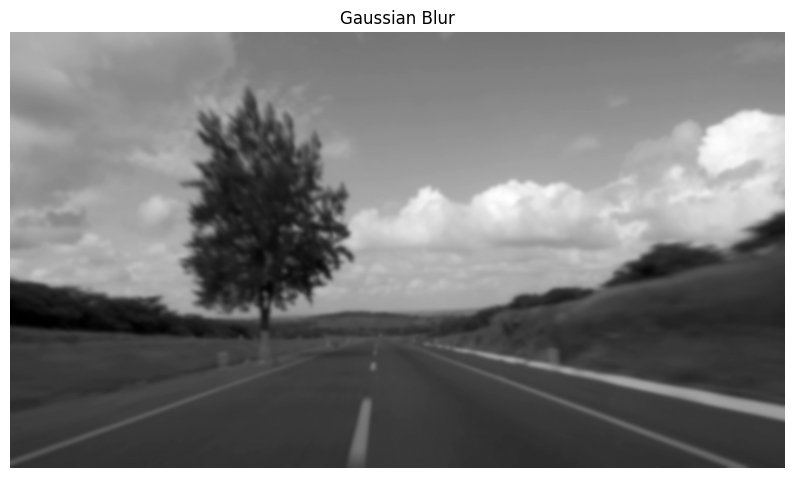

In [29]:
def gaussian_blur(img, kernel_size=15):
    return cv2.GaussianBlur(img, (kernel_size, kernel_size), 0)

blurred = gaussian_blur(gray)

plt.figure(figsize=(10, 6))
plt.imshow(blurred, cmap="gray")
plt.title("Gaussian Blur")
plt.axis("off")


### Edge Detection (Canny)

(np.float64(-0.5), np.float64(1279.5), np.float64(719.5), np.float64(-0.5))

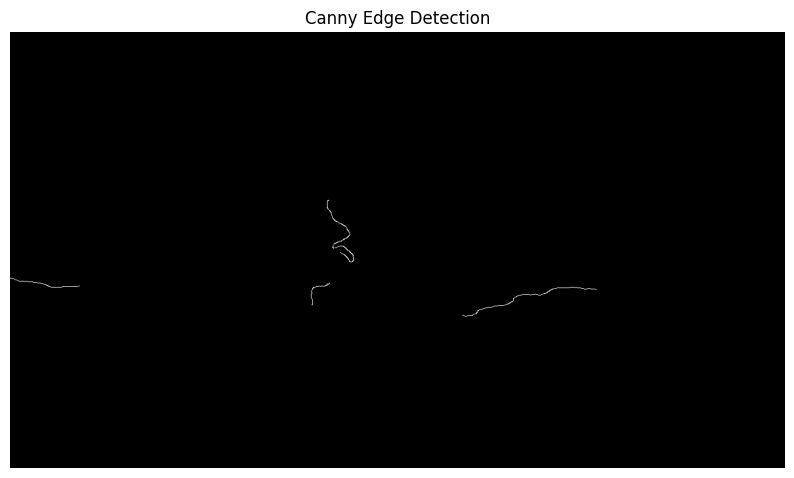

In [30]:
def canny(img, low_threshold=10, high_threshold=150):
    return cv2.Canny(img, low_threshold, high_threshold)

edges = canny(blurred)

plt.figure(figsize=(10, 6))
plt.imshow(edges, cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")


### Region of Interest (ROI)

(np.float64(-0.5), np.float64(1279.5), np.float64(719.5), np.float64(-0.5))

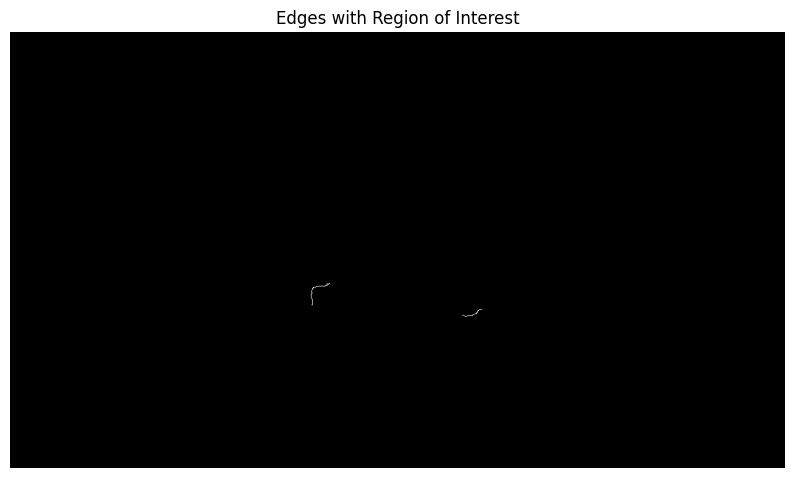

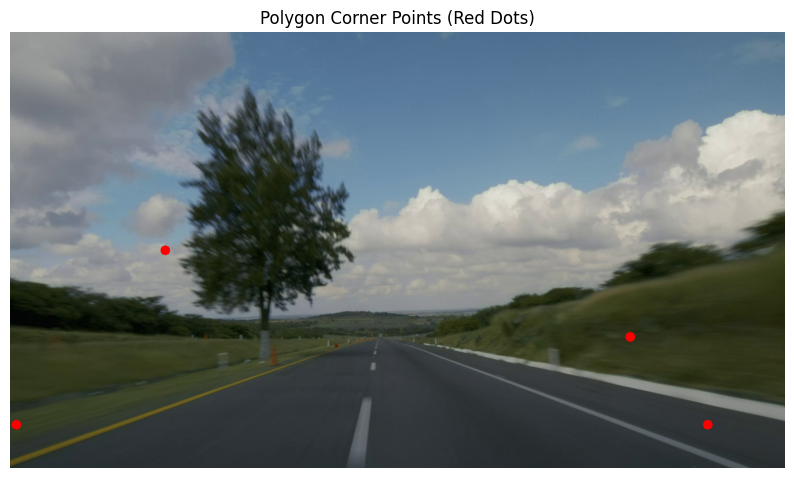

In [31]:
def region_of_interest(img):
    height, width = img.shape
    # Create a blank mask
    mask = np.zeros_like(img)

    # Define a trapezoid ROI
    polygon = np.array([[
        # bottom left corner
        (10, int(0.9 * height)),
        # top left corner
        (int(0.2 * width), int(0.5 * height)),
        # top right corner
        (int(0.8 * width), int(0.7 * height)),
        # bottom right corner
        (int(0.9 * width), int(0.9 * height))
    ]], dtype=np.int32)

    # Fill the polygon on the mask
    cv2.fillPoly(mask, polygon, 255)
    # Apply the mask to the input image
    masked_image = cv2.bitwise_and(img, mask)
    return masked_image, polygon

def draw_polygon_points(image, polygon, color=(255, 0, 0), radius=8):
    image_with_points = image.copy()
    for point in polygon[0]:
        cv2.circle(image_with_points, tuple(point), radius, color, -1)
    return image_with_points

roi_edges, polygon = region_of_interest(edges)
frame_with_points = draw_polygon_points(frame_rgb, polygon)

plt.figure(figsize=(10, 6))
plt.imshow(roi_edges, cmap="gray")
plt.title("Edges with Region of Interest")
plt.axis("off")

plt.figure(figsize=(10, 6))
plt.imshow(frame_with_points)
plt.title("Polygon Corner Points (Red Dots)")
plt.axis("off")


### Lane Detection using Hough Transform

(np.float64(-0.5), np.float64(1279.5), np.float64(719.5), np.float64(-0.5))

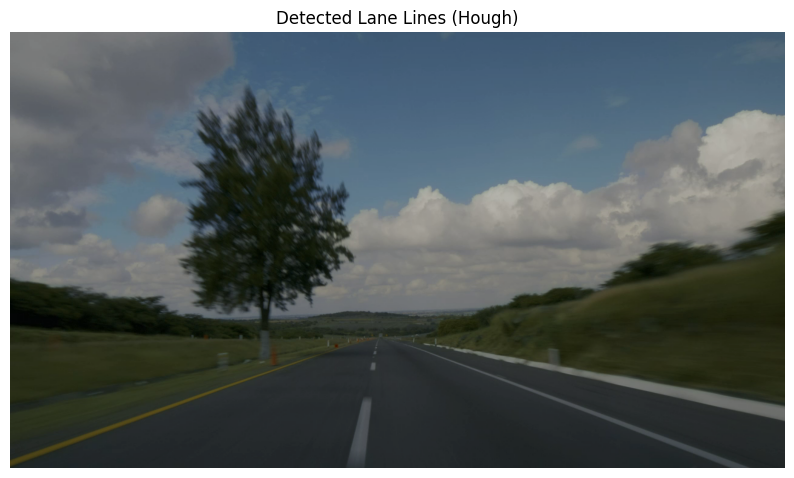

In [ ]:
# Detect Straight Lines Segments

def hough_lines(img):
    lines = cv2.HoughLinesP(
        img, # Input edge image
        rho=1, # Distance resolution in pixels
        theta=np.pi / 180, # Angle resolution in radians
        threshold=50, # Minimum number of votes (intersections in Hough grid cell)
        minLineLength=50, # Minimum length of line segments to be detected
        maxLineGap=150 # Maximum allowed gap between line segments to treat them as a single line
    )
    return lines

lines = hough_lines(roi_edges)

# Visualize Hough Lines
line_img = np.zeros_like(frame_rgb)

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(line_img, (x1, y1), (x2, y2), (255, 0, 0), 5)

overlay = cv2.addWeighted(frame_rgb, 0.8, line_img, 1, 0)

plt.figure(figsize=(10, 6))
plt.imshow(overlay)
plt.title("Detected Lane Lines (Hough)")
plt.axis("off")



### Processing the Full Video

In [33]:
# Apply Lane Detection Pipeline Frame by Frame

def process_frame(frame):
    gray = grayscale(frame)
    blur = gaussian_blur(gray)
    edges = canny(blur)
    roi, _ = region_of_interest(edges)
    lines = hough_lines(roi)

    line_img = np.zeros_like(frame)

    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            cv2.line(line_img, (x1, y1), (x2, y2), (255, 0, 0), 5)

    return cv2.addWeighted(frame, 0.8, line_img, 1, 0)


# Run on Video and Save Output

capture = cv2.VideoCapture(video_path)

fourcc = cv2.VideoWriter.fourcc(*"mp4v")
out = cv2.VideoWriter(
    "lane_detection_output.mp4",
    fourcc,
    capture.get(cv2.CAP_PROP_FPS),
    (int(capture.get(3)), int(capture.get(4)))
)

while capture.isOpened():
    ret, frame = capture.read()
    if not ret:
        break

    current_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    processed = process_frame(current_frame)
    processed_bgr = cv2.cvtColor(processed, cv2.COLOR_RGB2BGR)
    out.write(processed_bgr)

capture.release()
out.release()

print("Video processing complete. Output saved.")

Video processing complete. Output saved.


### Perspective Transform (Bird’s Eye View)

(np.float64(-0.5), np.float64(1279.5), np.float64(719.5), np.float64(-0.5))

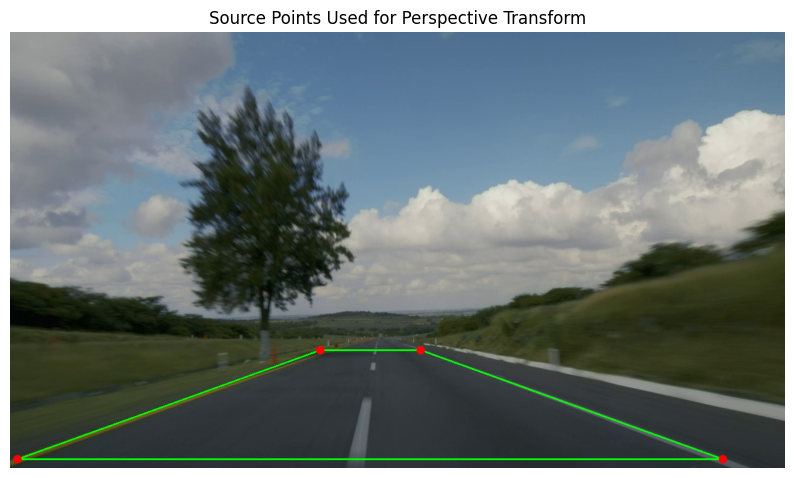

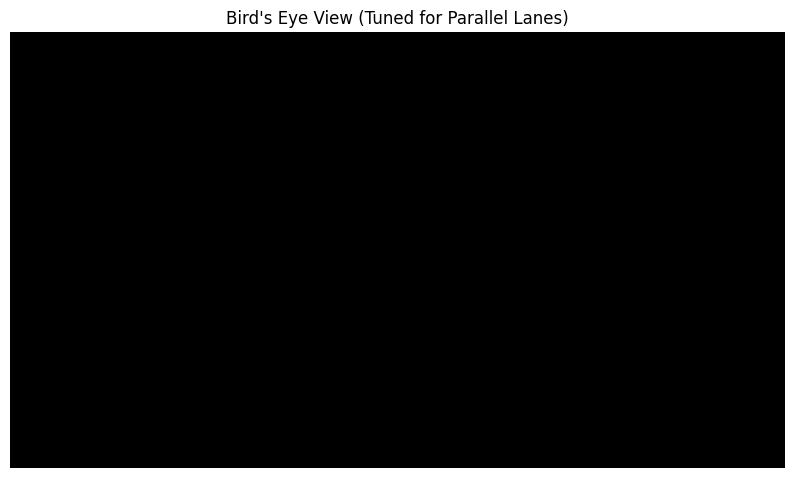

In [ ]:
def perspective_transform(img, src_points=None):
    height, width = img.shape

    # Use lane-aligned source points instead of image-corner ROI points.
    # Tweak these fractions for your camera/video until lane edges look vertical in BEV.
    if src_points is None:
        src = np.float32([
            [int(0.4 * width), int(0.73 * height)],     # top-left on left lane
            [int(0.53 * width), int(0.73 * height)],     # top-right on right lane
            [int(0.92 * width), int(0.98 * height)],    # bottom-right on right lane
            [int(0.01 * width), int(0.98 * height)]     # bottom-left on left lane
        ])
    else:
        src = np.float32(src_points)

    # Rectangular destination with equal top/bottom width -> parallel lane lines.
    dst_margin = int(0.1 * width)
    dst = np.float32([
        [dst_margin, 0.1 * height],             # top-left corner of in BEV
        [width - dst_margin, 0.1 * height],     # top-right corner of in BEV
        [width - dst_margin, height],           # bottom-right corner of in BEV
        [dst_margin, height]                    # bottom-left corner of in BEV
    ])

    # Compute perspective transform matrix and its inverse
    transformationMatrix = cv2.getPerspectiveTransform(src, dst)
    inverseTransformMatrix = cv2.getPerspectiveTransform(dst, src)
    
    # Apply perspective warp to get bird's eye view
    warped = cv2.warpPerspective(img, transformationMatrix, (width, height))
    
    return warped, transformationMatrix, inverseTransformMatrix, src, dst

warped_edges, transformationMatrix, inverseTransformMatrix, src, dst = perspective_transform(roi_edges)

# Visual debug: show selected source quadrilateral on original frame.
frame_src = frame_rgb.copy()
src_int = src.astype(np.int32)
cv2.polylines(frame_src, [src_int], True, (0, 255, 0), 2)
for p in src_int:
    cv2.circle(frame_src, tuple(p), 7, (255, 0, 0), -1)

plt.figure(figsize=(10, 6))
plt.imshow(frame_src)
plt.title("Source Points Used for Perspective Transform")
plt.axis("off")

plt.figure(figsize=(10, 6))
plt.imshow(warped_edges, cmap="gray")
plt.title("Bird's Eye View (Tuned for Parallel Lanes)")
plt.axis("off")

In [35]:
# Hough transform on BEV image - to try

![Alt text](HoughLinesBEV.png)

(np.float64(-0.5), np.float64(1279.5), np.float64(719.5), np.float64(-0.5))

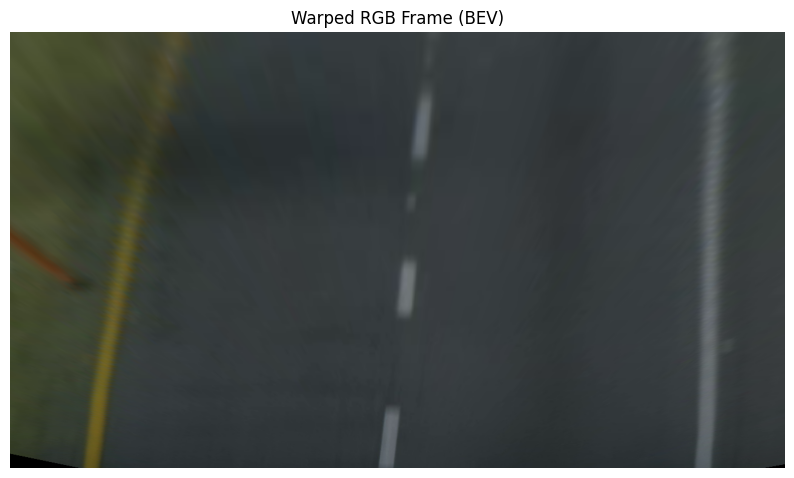

In [36]:
# Apply perspective transform to original RGB frame for visualization (not just edges)

# Ensure we have a BEV edge image
if 'warped_edges' not in globals():
    warped_edges, transformationMatrix, Minv, src, dst = perspective_transform(roi_edges)

# Prepare BEV RGB background for visualization
height, width = warped_edges.shape
warped_frame_rgb = cv2.warpPerspective(frame_rgb, transformationMatrix, (width, height))

plt.figure(figsize=(10, 6))
plt.imshow(warped_frame_rgb)
plt.title("Warped RGB Frame (BEV)")
plt.axis("off")

### Create a binary image

(np.float64(-0.5), np.float64(1279.5), np.float64(719.5), np.float64(-0.5))

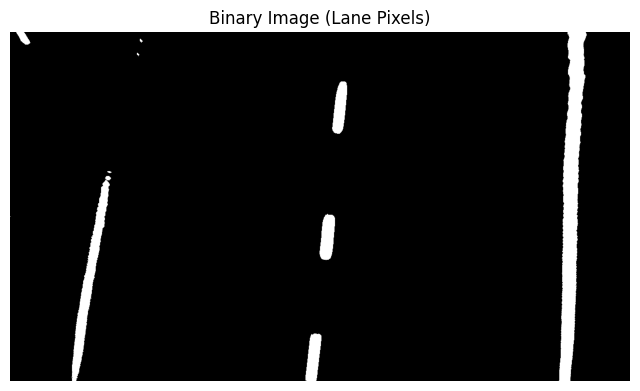

In [37]:
def binary_threshold(img, thresh_min=80, thresh_max=255):
    binary = np.zeros_like(img)
    binary[(img >= thresh_min) & (img <= thresh_max)] = 1
    return binary

gray_warped = grayscale(warped_frame_rgb)
binary_warped = binary_threshold(gray_warped)

plt.figure(figsize=(8, 5))
plt.imshow(binary_warped, cmap='gray')
plt.title("Binary Image (Lane Pixels)")
plt.axis("off")


### Histogram Analysis - Finding Lane Bases

Text(0, 0.5, 'Pixel count')

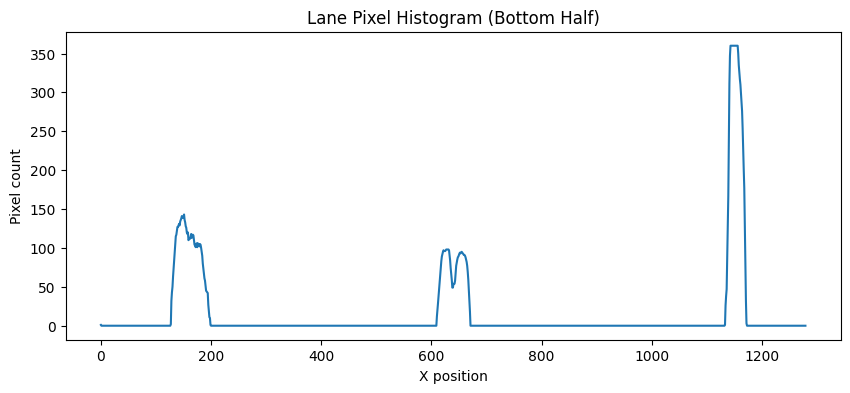

In [38]:

def compute_histogram(binary_img):
    return np.sum(binary_img[binary_img.shape[0]//2:, :], axis=0)

histogram = compute_histogram(binary_warped)

plt.figure(figsize=(10, 4))
plt.plot(histogram)
plt.title("Lane Pixel Histogram (Bottom Half)")
plt.xlabel("X position")
plt.ylabel("Pixel count")


### Extract Left and Right Lane Starting Positions

In [39]:

# Find peaks in histogram for left and right lane base positions
midpoint = histogram.shape[0] // 2 # Use midpoint of histogram to separate left and right halves
leftx_base = np.argmax(histogram[:midpoint]) # Find peak in left half
rightx_base = np.argmax(histogram[midpoint:]) + midpoint # Find peak in right half and adjust index by adding midpoint

print("Left lane base:", leftx_base)
print("Right lane base:", rightx_base)


Left lane base: 151
Right lane base: 1143


### Sliding Window Search

(np.float64(-0.5), np.float64(1279.5), np.float64(719.5), np.float64(-0.5))

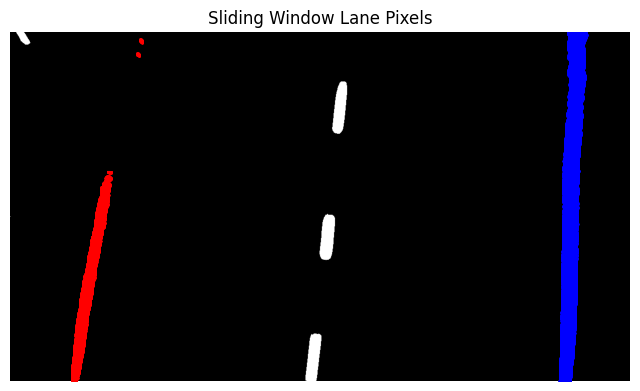

In [40]:

def sliding_window_search(binary_warped, nwindows=9, margin=100, minpix=50):
    # input params meaning:
    # nwindows: number of sliding windows to use vertically
    # margin: width of the windows +/- margin
    # minpix: minimum number of pixels found to recenter window

    height = binary_warped.shape[0]
    window_height = height // nwindows

    # Identify the x and y positions of all nonzero pixels in the image
    nonzero = binary_warped.nonzero()
    nonzeroy = np.array(nonzero[0])
    nonzerox = np.array(nonzero[1])

    # Current positions to be updated for each window
    leftx_current = leftx_base
    rightx_current = rightx_base

    left_lane_inds = []
    right_lane_inds = []

    for window in range(nwindows):
        # Define window boundaries
        win_y_low = height - (window + 1) * window_height
        win_y_high = height - window * window_height
        win_xleft_low = leftx_current - margin
        win_xleft_high = leftx_current + margin
        win_xright_low = rightx_current - margin
        win_xright_high = rightx_current + margin
        
        # Identify the nonzero pixels in x and y within the window for left lane boundary
        good_left_inds = (
            (nonzeroy >= win_y_low) &
            (nonzeroy < win_y_high) &
            (nonzerox >= win_xleft_low) &
            (nonzerox < win_xleft_high)
        ).nonzero()[0]

        # Identify the nonzero pixels in x and y within the window for right lane boundary
        good_right_inds = (
            (nonzeroy >= win_y_low) &
            (nonzeroy < win_y_high) &
            (nonzerox >= win_xright_low) &
            (nonzerox < win_xright_high)
        ).nonzero()[0]

        # Append these indices to the lists
        left_lane_inds.append(good_left_inds)
        right_lane_inds.append(good_right_inds)

        # If you found > minpix pixels, recenter next window on their mean position
        if len(good_left_inds) > minpix:
            leftx_current = int(np.mean(nonzerox[good_left_inds]))

        if len(good_right_inds) > minpix:
            rightx_current = int(np.mean(nonzerox[good_right_inds]))

    # Concatenate the arrays of indices
    left_lane_inds = np.concatenate(left_lane_inds)
    right_lane_inds = np.concatenate(right_lane_inds)

    leftx = nonzerox[left_lane_inds]
    lefty = nonzeroy[left_lane_inds]
    rightx = nonzerox[right_lane_inds]
    righty = nonzeroy[right_lane_inds]

    return leftx, lefty, rightx, righty


# Apply Sliding-Window Search on Bird's Eye View Binary Image
leftx, lefty, rightx, righty = sliding_window_search(binary_warped)

plt.figure(figsize=(8, 6))
plt.imshow(binary_warped, cmap='gray')
plt.scatter(leftx, lefty, s=1, c='red')
plt.scatter(rightx, righty, s=1, c='blue')
plt.title("Sliding Window Lane Pixels")
plt.axis('off')



### Polynomial Lane Fitting

Left lane polynomial: [ 1.03674920e-04 -2.73394796e-01  2.74919083e+02]
Right lane polynomial: [ 1.83263517e-05 -4.53261462e-02  1.17119435e+03]


(np.float64(-0.5), np.float64(1279.5), np.float64(719.5), np.float64(-0.5))

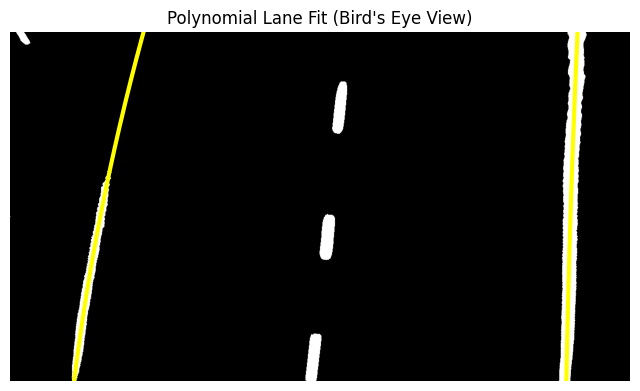

In [41]:

left_fit = np.polyfit(lefty, leftx, 2)
right_fit = np.polyfit(righty, rightx, 2)

print("Left lane polynomial:", left_fit)
print("Right lane polynomial:", right_fit)

# Visualize polynomial fits on BEV image
ploty = np.linspace(0, binary_warped.shape[0] - 1, binary_warped.shape[0])

left_fitx = left_fit[0] * ploty**2 + left_fit[1] * ploty + left_fit[2]
right_fitx = right_fit[0] * ploty**2 + right_fit[1] * ploty + right_fit[2]

plt.figure(figsize=(8, 6))
plt.imshow(binary_warped, cmap='gray')
plt.plot(left_fitx, ploty, color='yellow', linewidth=3)
plt.plot(right_fitx, ploty, color='yellow', linewidth=3)
plt.title("Polynomial Lane Fit (Bird's Eye View)")
plt.axis("off")

In [42]:
# Identify both lane lines in BEV, fit polynomials, and visualize the result. - to try

![Alt text](SlidingWindow3Lines.png)